In [1]:
# Install and import all required libraries
!pip install pandas numpy matplotlib seaborn faker apache-airflow -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from faker import Faker
import random
import sqlite3
import json
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)
fake = Faker()

print("All libraries imported successfully!")
print("Let's build an Energy Data Analytics Pipeline!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 492.8/492.8 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.3/96.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.7/158.7 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.7/74.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 2

In [3]:
# Generate Energy Data Pipeline Dataset
n_plants = 50
n_days = 365

energy_sources = ['Solar', 'Wind', 'Natural Gas', 'Coal', 'Nuclear',
                  'Hydro', 'Geothermal', 'Biomass']
regions = ['Northeast', 'Southeast', 'Midwest', 'Southwest', 'West Coast']
plant_status = ['Operational', 'Maintenance', 'Offline', 'Commissioning']

# Generate power plants
plants = []
for i in range(n_plants):
    source = random.choice(energy_sources)
    capacity_map = {'Solar': 500, 'Wind': 400, 'Natural Gas': 1000,
                    'Coal': 800, 'Nuclear': 1200, 'Hydro': 600,
                    'Geothermal': 300, 'Biomass': 250}
    plants.append({
        'plant_id': f'PLT{i+1:03d}',
        'plant_name': f'{fake.city()} {source} Plant',
        'energy_source': source,
        'region': random.choice(regions),
        'capacity_mw': capacity_map[source] * random.uniform(0.5, 2.0),
        'operational_year': random.randint(1990, 2023),
        'status': random.choice(plant_status),
        'latitude': round(random.uniform(25, 48), 4),
        'longitude': round(random.uniform(-120, -70), 4)
    })

plants_df = pd.DataFrame(plants)

# Generate daily energy production records
records = []
start_date = datetime.now() - timedelta(days=n_days)

for day in range(n_days):
    date = start_date + timedelta(days=day)
    for _, plant in plants_df.iterrows():
        # Efficiency based on source and season
        month = date.month
        season_factor = {
            'Solar': 1.3 if month in [6,7,8] else 0.7 if month in [12,1,2] else 1.0,
            'Wind': 1.2 if month in [3,4,11,12] else 0.8,
            'Natural Gas': 1.1, 'Coal': 1.0, 'Nuclear': 0.98,
            'Hydro': 1.2 if month in [4,5,6] else 0.8,
            'Geothermal': 0.95, 'Biomass': 0.90
        }[plant['energy_source']]

        efficiency = random.uniform(0.70, 0.95) * season_factor
        efficiency = min(0.99, max(0.40, efficiency))
        production_mwh = plant['capacity_mw'] * 24 * efficiency

        cost_per_mwh = {
            'Solar': 25, 'Wind': 30, 'Natural Gas': 45,
            'Coal': 35, 'Nuclear': 20, 'Hydro': 15,
            'Geothermal': 28, 'Biomass': 38
        }[plant['energy_source']]

        emission_factor = {
            'Solar': 0, 'Wind': 0, 'Natural Gas': 0.45,
            'Coal': 0.82, 'Nuclear': 0, 'Hydro': 0.01,
            'Geothermal': 0.05, 'Biomass': 0.23
        }[plant['energy_source']]

        records.append({
            'record_id': f'REC{len(records)+1:07d}',
            'plant_id': plant['plant_id'],
            'date': date.strftime('%Y-%m-%d'),
            'energy_source': plant['energy_source'],
            'region': plant['region'],
            'production_mwh': round(production_mwh, 2),
            'efficiency_pct': round(efficiency * 100, 2),
            'operating_cost': round(production_mwh * cost_per_mwh, 2),
            'revenue': round(production_mwh * random.uniform(55, 85), 2),
            'co2_emissions_tons': round(production_mwh * emission_factor, 2),
            'downtime_hours': round(random.uniform(0, 2), 2),
            'maintenance_flag': 1 if random.random() < 0.05 else 0
        })

energy_df = pd.DataFrame(records)
energy_df['date'] = pd.to_datetime(energy_df['date'])
energy_df['profit'] = energy_df['revenue'] - energy_df['operating_cost']

print(f"Dataset generated successfully!")
print(f"Total records: {len(energy_df):,}")
print(f"Plants: {n_plants}")
print(f"Days of data: {n_days}")
print(f"Total Production: {energy_df['production_mwh'].sum()/1e6:.2f} TWh")
print(f"Total Revenue: ${energy_df['revenue'].sum()/1e9:.2f}B")
print(f"Total CO2 Emissions: {energy_df['co2_emissions_tons'].sum()/1e6:.2f}M tons")
print(f"Avg Efficiency: {energy_df['efficiency_pct'].mean():.2f}%")

Dataset generated successfully!
Total records: 18,250
Plants: 50
Days of data: 365
Total Production: 267.74 TWh
Total Revenue: $18.70B
Total CO2 Emissions: 56.96M tons
Avg Efficiency: 80.33%


In [4]:
# ELT Pipeline Implementation
import sqlite3
from datetime import datetime

class EnergyDataPipeline:
    def __init__(self):
        self.conn = sqlite3.connect('energy_analytics.db')
        self.pipeline_log = []

    def log(self, stage, message, records=0):
        entry = {
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'stage': stage,
            'message': message,
            'records_processed': records
        }
        self.pipeline_log.append(entry)
        print(f"[{entry['timestamp']}] [{stage}] {message} | Records: {records:,}")

    # ── EXTRACT ────────────────────────────────────
    def extract(self):
        self.log('EXTRACT', 'Starting data extraction from sources', len(energy_df))

        # Raw data validation
        missing = energy_df.isnull().sum().sum()
        duplicates = energy_df.duplicated().sum()
        self.log('EXTRACT', f'Validation — Missing: {missing}, Duplicates: {duplicates}')

        # Save raw data
        energy_df.to_sql('raw_energy_data', self.conn,
                         if_exists='replace', index=False)
        plants_df.to_sql('raw_plants', self.conn,
                         if_exists='replace', index=False)
        self.log('EXTRACT', 'Raw data saved to database', len(energy_df))
        return energy_df.copy()

    # ── LOAD RAW ────────────────────────────────────
    def load_raw(self, df):
        self.log('LOAD', 'Loading raw data to staging tables', len(df))
        df.to_sql('staging_energy', self.conn,
                  if_exists='replace', index=False)
        self.log('LOAD', 'Staging tables populated successfully', len(df))
        return df

    # ── TRANSFORM ──────────────────────────────────
    def transform(self, df):
        self.log('TRANSFORM', 'Starting data transformation')

        # 1. Clean and standardize
        df['date'] = pd.to_datetime(df['date'])
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        df['quarter'] = df['date'].dt.quarter
        df['month_name'] = df['date'].dt.strftime('%b')
        df['is_renewable'] = df['energy_source'].isin(
            ['Solar', 'Wind', 'Hydro', 'Geothermal', 'Biomass']).astype(int)
        self.log('TRANSFORM', 'Date features engineered', len(df))

        # 2. Calculate KPIs
        df['profit_margin'] = ((df['profit'] / df['revenue']) * 100).round(2)
        df['cost_per_mwh'] = (df['operating_cost'] / df['production_mwh']).round(2)
        df['revenue_per_mwh'] = (df['revenue'] / df['production_mwh']).round(2)
        df['carbon_intensity'] = (df['co2_emissions_tons'] /
                                   df['production_mwh']).round(4)
        self.log('TRANSFORM', 'KPI metrics calculated', len(df))

        # 3. Anomaly detection
        df['efficiency_zscore'] = ((df['efficiency_pct'] -
                                    df['efficiency_pct'].mean()) /
                                    df['efficiency_pct'].std()).round(3)
        df['is_anomaly'] = (df['efficiency_zscore'].abs() > 2.5).astype(int)
        anomalies = df['is_anomaly'].sum()
        self.log('TRANSFORM', f'Anomaly detection complete — {anomalies} anomalies found', anomalies)

        # 4. Rolling averages
        df = df.sort_values('date')
        df['rolling_7d_production'] = df.groupby('plant_id')['production_mwh'].transform(
            lambda x: x.rolling(7, min_periods=1).mean()).round(2)
        df['rolling_30d_revenue'] = df.groupby('plant_id')['revenue'].transform(
            lambda x: x.rolling(30, min_periods=1).mean()).round(2)
        self.log('TRANSFORM', 'Rolling averages computed', len(df))

        return df

    # ── LOAD TRANSFORMED ────────────────────────────
    def load_transformed(self, df):
        self.log('LOAD', 'Loading transformed data to analytics tables')

        # Main analytics table
        df.to_sql('analytics_energy', self.conn,
                  if_exists='replace', index=False)

        # Aggregated summary tables
        daily_summary = df.groupby(['date', 'energy_source', 'region']).agg(
            total_production=('production_mwh', 'sum'),
            total_revenue=('revenue', 'sum'),
            total_cost=('operating_cost', 'sum'),
            avg_efficiency=('efficiency_pct', 'mean'),
            total_co2=('co2_emissions_tons', 'sum')
        ).reset_index()
        daily_summary.to_sql('daily_summary', self.conn,
                             if_exists='replace', index=False)

        monthly_summary = df.groupby(['year', 'month', 'energy_source']).agg(
            total_production=('production_mwh', 'sum'),
            total_revenue=('revenue', 'sum'),
            avg_efficiency=('efficiency_pct', 'mean'),
            total_co2=('co2_emissions_tons', 'sum')
        ).reset_index()
        monthly_summary.to_sql('monthly_summary', self.conn,
                               if_exists='replace', index=False)

        self.log('LOAD', 'Analytics tables created', len(df))
        self.log('LOAD', f'Daily summary: {len(daily_summary):,} rows')
        self.log('LOAD', f'Monthly summary: {len(monthly_summary):,} rows')
        return df

    # ── RUN PIPELINE ────────────────────────────────
    def run(self):
        print("\n" + "="*60)
        print("⚡ ENERGY DATA ANALYTICS PIPELINE STARTING")
        print("="*60 + "\n")

        # ELT Steps
        raw_df = self.extract()
        staged_df = self.load_raw(raw_df)
        transformed_df = self.transform(staged_df)
        final_df = self.load_transformed(transformed_df)

        print("\n" + "="*60)
        print("PIPELINE COMPLETED SUCCESSFULLY")
        print("="*60)
        print(f"Total records processed: {len(final_df):,}")
        print(f"Pipeline stages: {len(set([l['stage'] for l in self.pipeline_log]))}")
        print(f"Total log entries: {len(self.pipeline_log)}")

        return final_df, pd.DataFrame(self.pipeline_log)

# Run the pipeline
pipeline = EnergyDataPipeline()
final_df, log_df = pipeline.run()


⚡ ENERGY DATA ANALYTICS PIPELINE STARTING

[2026-05-30 21:43:20] [EXTRACT] Starting data extraction from sources | Records: 18,250
[2026-05-30 21:43:20] [EXTRACT] Validation — Missing: 0, Duplicates: 0 | Records: 0
[2026-05-30 21:43:20] [EXTRACT] Raw data saved to database | Records: 18,250
[2026-05-30 21:43:20] [LOAD] Loading raw data to staging tables | Records: 18,250
[2026-05-30 21:43:20] [LOAD] Staging tables populated successfully | Records: 18,250
[2026-05-30 21:43:20] [TRANSFORM] Starting data transformation | Records: 0
[2026-05-30 21:43:20] [TRANSFORM] Date features engineered | Records: 18,250
[2026-05-30 21:43:20] [TRANSFORM] KPI metrics calculated | Records: 18,250
[2026-05-30 21:43:20] [TRANSFORM] Anomaly detection complete — 89 anomalies found | Records: 89
[2026-05-30 21:43:20] [TRANSFORM] Rolling averages computed | Records: 18,250
[2026-05-30 21:43:20] [LOAD] Loading transformed data to analytics tables | Records: 0
[2026-05-30 21:43:21] [LOAD] Analytics tables creat

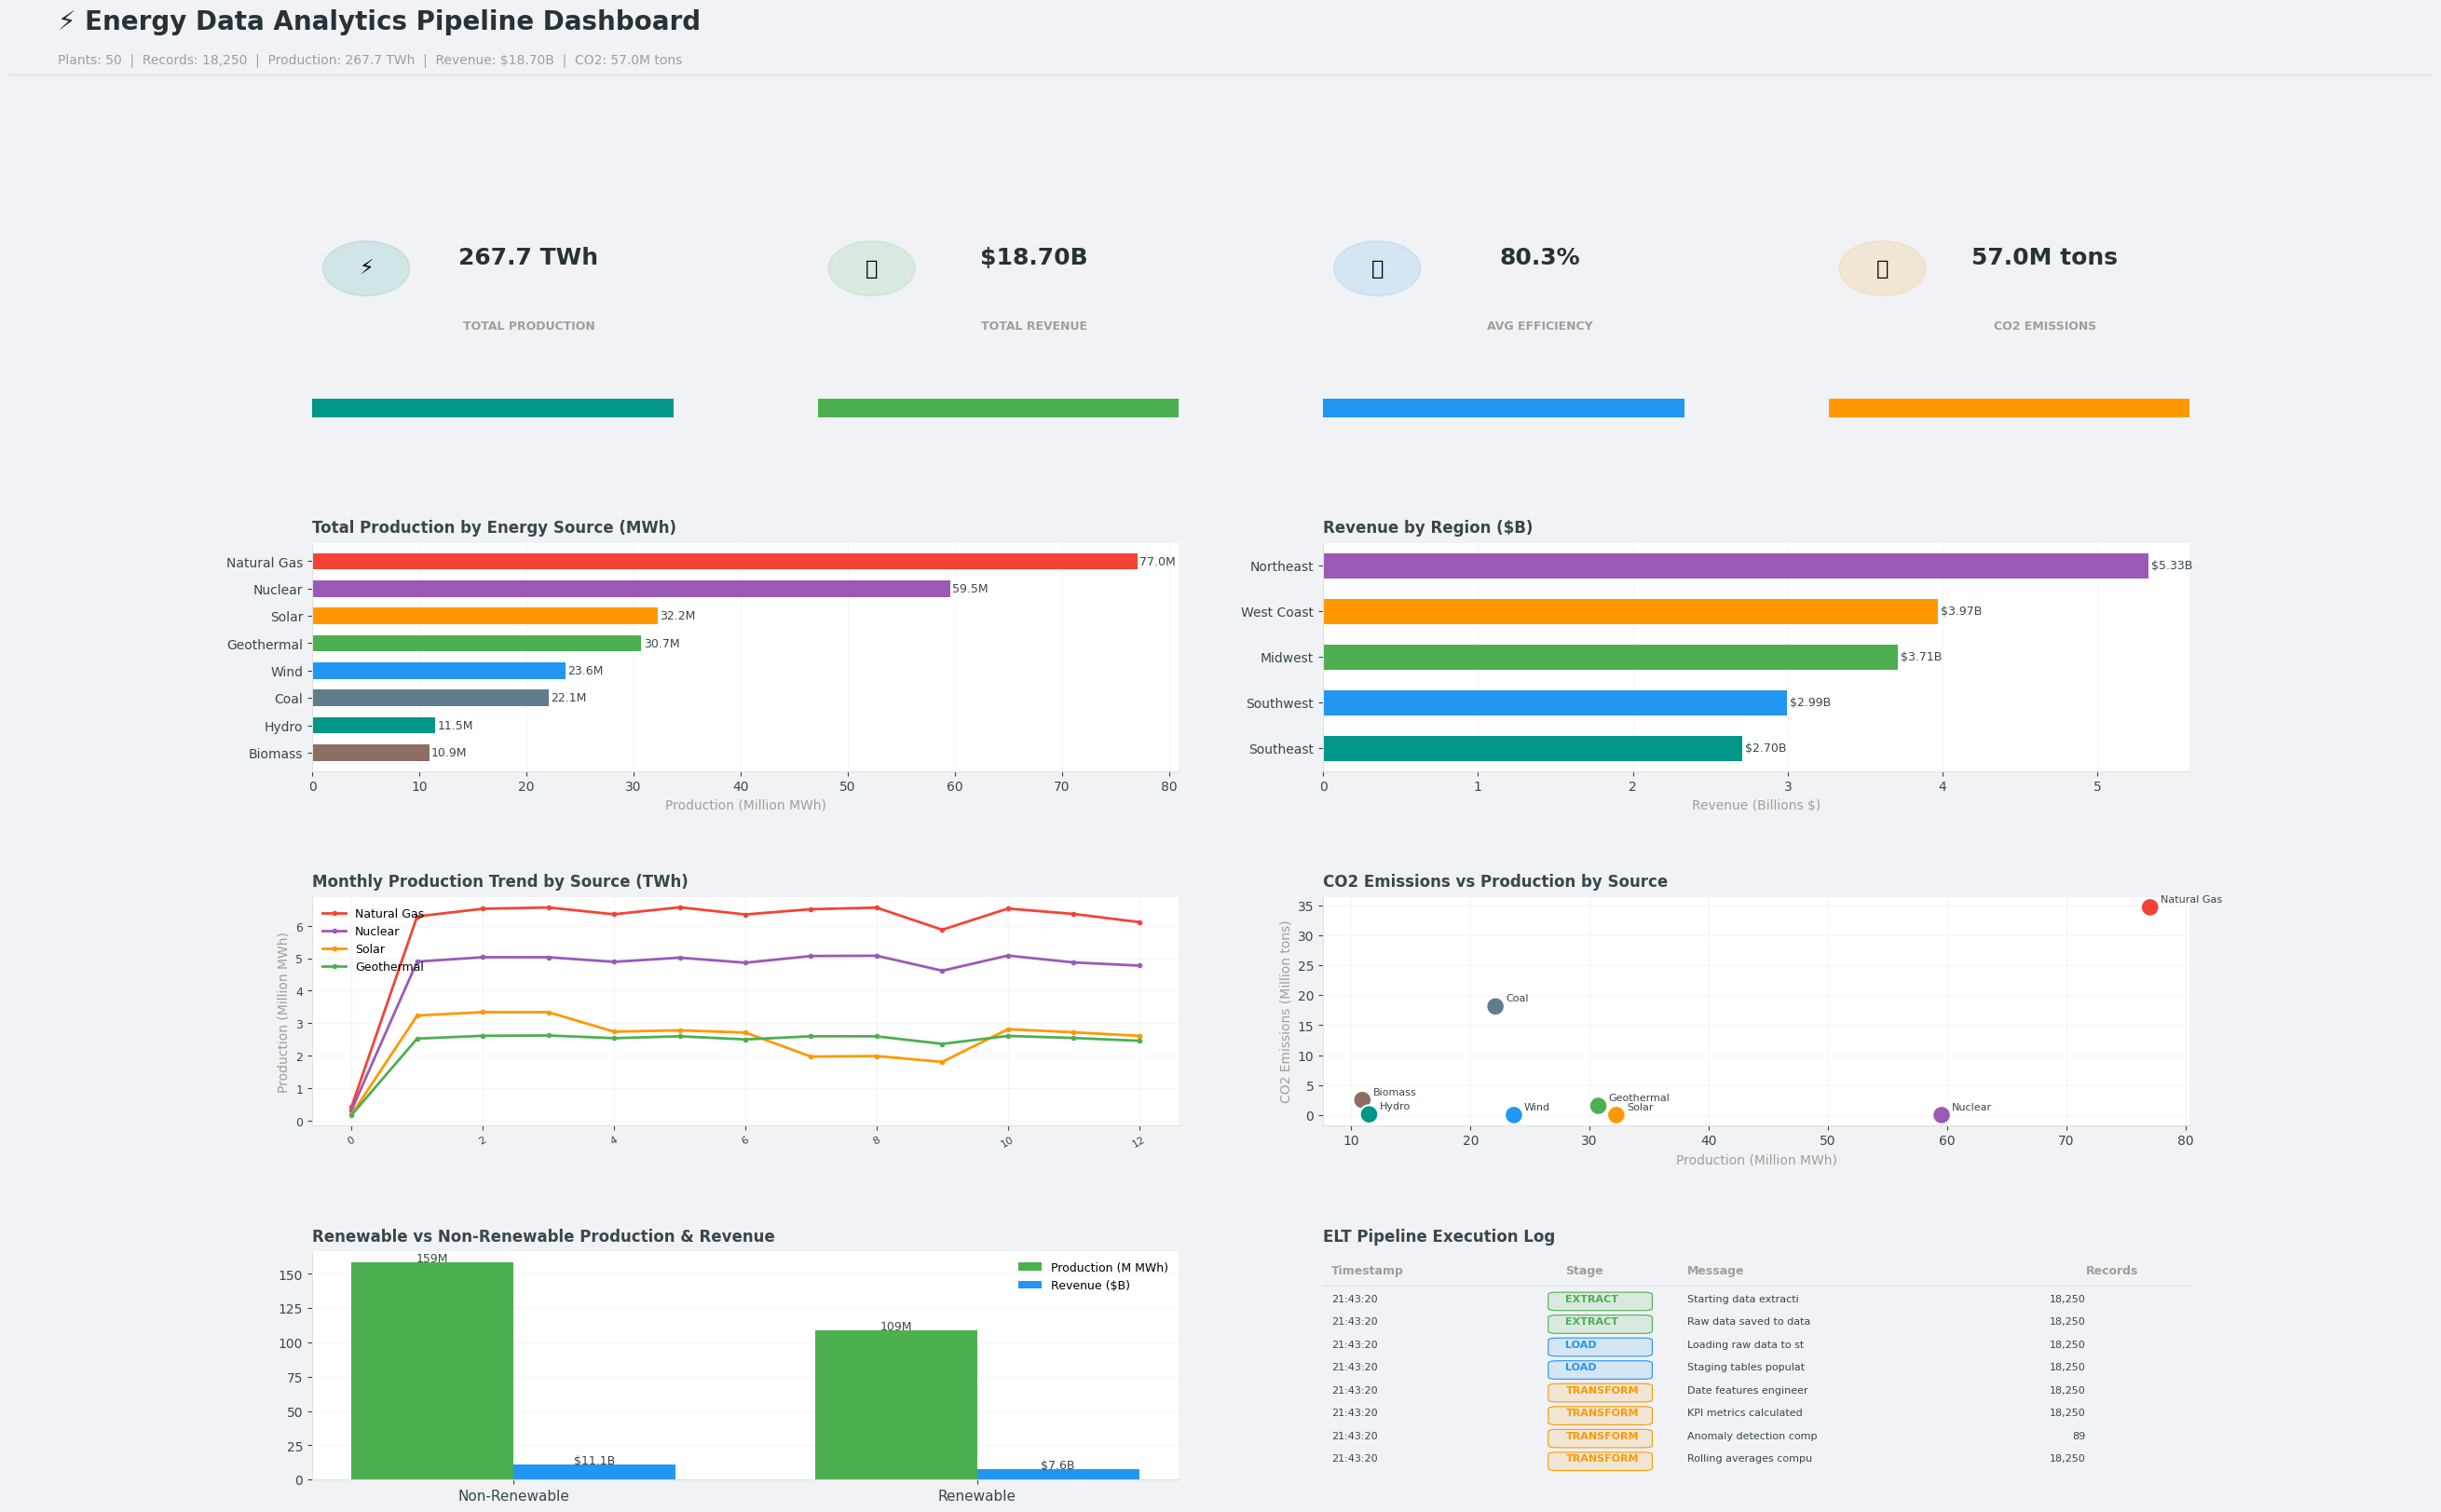

Energy Pipeline Dashboard created!


In [5]:
# Energy Data Analytics Pipeline Dashboard
plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

plt.style.use('default')
fig = plt.figure(figsize=(26, 18))
fig.patch.set_facecolor('#f0f2f5')
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.40)

# Colors
TEAL = '#009688'
GREEN = '#4CAF50'
BLUE = '#2196F3'
ORANGE = '#FF9800'
RED = '#f44336'
PURPLE = '#9b59b6'
COAL_COLOR = '#607D8B'
CARD = '#ffffff'
BORDER = '#e0e0e0'
TEXT = '#37474f'
GRAY = '#9e9e9e'

def card(ax):
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_color(BORDER)
        spine.set_linewidth(0.8)

# ── HEADER ─────────────────────────────────────────
fig.text(0.02, 0.975, '⚡ Energy Data Analytics Pipeline Dashboard',
         ha='left', fontsize=20, fontweight='bold', color='#263238')
fig.text(0.02, 0.955,
         f'Plants: 50  |  Records: {len(final_df):,}  |  Production: {final_df["production_mwh"].sum()/1e6:.1f} TWh  |  Revenue: ${final_df["revenue"].sum()/1e9:.2f}B  |  CO2: {final_df["co2_emissions_tons"].sum()/1e6:.1f}M tons',
         ha='left', fontsize=10, color=GRAY)
fig.add_artist(plt.Line2D([0.0, 1.0], [0.948, 0.948],
               color=BORDER, linewidth=1.0, transform=fig.transFigure))

# ── KPI CARDS ──────────────────────────────────────
kpis = [
    ('TOTAL PRODUCTION', f'{final_df["production_mwh"].sum()/1e6:.1f} TWh', TEAL, '⚡'),
    ('TOTAL REVENUE', f'${final_df["revenue"].sum()/1e9:.2f}B', GREEN, '💰'),
    ('AVG EFFICIENCY', f'{final_df["efficiency_pct"].mean():.1f}%', BLUE, '📊'),
    ('CO2 EMISSIONS', f'{final_df["co2_emissions_tons"].sum()/1e6:.1f}M tons', ORANGE, '🌍'),
]

for idx, (label, value, color, icon) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs[0, idx])
    card(ax_kpi)
    ax_kpi.axis('off')
    circle = plt.Circle((0.15, 0.65), 0.12, color=color+'22',
                        transform=ax_kpi.transAxes)
    ax_kpi.add_patch(circle)
    ax_kpi.text(0.15, 0.65, icon, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=16)
    ax_kpi.text(0.60, 0.70, value, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=18,
                fontweight='bold', color='#263238')
    ax_kpi.text(0.60, 0.40, label, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=9,
                color=GRAY, fontweight='bold')
    ax_kpi.add_patch(mpatches.FancyBboxPatch((0.0, 0.0), 1.0, 0.08,
                      boxstyle="square,pad=0", facecolor=color,
                      edgecolor='none', transform=ax_kpi.transAxes))

# ── CHART 1: Production by Energy Source ───────────
ax1 = fig.add_subplot(gs[1, 0:2])
card(ax1)
ax1.set_title('Total Production by Energy Source (MWh)', color=TEXT,
              fontweight='bold', loc='left', pad=8)
source_prod = final_df.groupby('energy_source')['production_mwh'].sum().sort_values()
source_colors = {
    'Solar': ORANGE, 'Wind': BLUE, 'Nuclear': PURPLE,
    'Natural Gas': RED, 'Coal': COAL_COLOR, 'Hydro': TEAL,
    'Geothermal': GREEN, 'Biomass': '#8D6E63'
}
colors_list = [source_colors.get(s, BLUE) for s in source_prod.index]
bars1 = ax1.barh(source_prod.index, source_prod.values/1e6,
                 color=colors_list, edgecolor='none', height=0.6)
ax1.tick_params(colors=TEXT, labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', color='#f5f5f5', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.set_xlabel('Production (Million MWh)', color=GRAY)
for bar, val in zip(bars1, source_prod.values/1e6):
    ax1.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}M', va='center', fontsize=9, color=TEXT)

# ── CHART 2: Revenue by Region ─────────────────────
ax2 = fig.add_subplot(gs[1, 2:4])
card(ax2)
ax2.set_title('Revenue by Region ($B)', color=TEXT,
              fontweight='bold', loc='left', pad=8)
region_rev = final_df.groupby('region')['revenue'].sum().sort_values()
region_colors = [TEAL, BLUE, GREEN, ORANGE, PURPLE]
bars2 = ax2.barh(region_rev.index, region_rev.values/1e9,
                 color=region_colors[:len(region_rev)], edgecolor='none', height=0.55)
ax2.tick_params(colors=TEXT, labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='x', color='#f5f5f5', linewidth=0.8)
ax2.set_axisbelow(True)
ax2.set_xlabel('Revenue (Billions $)', color=GRAY)
for bar, val in zip(bars2, region_rev.values/1e9):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'${val:.2f}B', va='center', fontsize=9, color=TEXT)

# ── CHART 3: Monthly Production Trend ──────────────
ax3 = fig.add_subplot(gs[2, 0:2])
card(ax3)
ax3.set_title('Monthly Production Trend by Source (TWh)', color=TEXT,
              fontweight='bold', loc='left', pad=8)
monthly = final_df.groupby(['year', 'month', 'energy_source'])['production_mwh'].sum().reset_index()
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)
top_sources = final_df.groupby('energy_source')['production_mwh'].sum().nlargest(4).index
for source in top_sources:
    src_data = monthly[monthly['energy_source']==source].sort_values('period')
    ax3.plot(range(len(src_data)), src_data['production_mwh']/1e6,
             linewidth=2, label=source,
             color=source_colors.get(source, BLUE), marker='o', markersize=3)
ax3.tick_params(colors=TEXT, labelsize=8, axis='x', rotation=30)
ax3.tick_params(colors=TEXT, labelsize=9, axis='y')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(color='#f5f5f5', linewidth=0.8)
ax3.set_axisbelow(True)
ax3.set_ylabel('Production (Million MWh)', color=GRAY)
ax3.legend(fontsize=9, frameon=False, loc='upper left')

# ── CHART 4: CO2 Emissions by Source ───────────────
ax4 = fig.add_subplot(gs[2, 2:4])
card(ax4)
ax4.set_title('CO2 Emissions vs Production by Source', color=TEXT,
              fontweight='bold', loc='left', pad=8)
source_stats = final_df.groupby('energy_source').agg(
    production=('production_mwh', 'sum'),
    co2=('co2_emissions_tons', 'sum')
).reset_index()
scatter_colors = [source_colors.get(s, BLUE) for s in source_stats['energy_source']]
scatter = ax4.scatter(source_stats['production']/1e6,
                      source_stats['co2']/1e6,
                      c=scatter_colors, s=200, edgecolors='white',
                      linewidth=1.5, zorder=3)
for _, row in source_stats.iterrows():
    ax4.annotate(row['energy_source'],
                (row['production']/1e6, row['co2']/1e6),
                textcoords='offset points', xytext=(8, 4),
                fontsize=8, color=TEXT)
ax4.set_xlabel('Production (Million MWh)', color=GRAY)
ax4.set_ylabel('CO2 Emissions (Million tons)', color=GRAY)
ax4.tick_params(colors=TEXT)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(color='#f5f5f5', linewidth=0.8)
ax4.set_axisbelow(True)

# ── CHART 5: Renewable vs Non-Renewable ────────────
ax5 = fig.add_subplot(gs[3, 0:2])
card(ax5)
ax5.set_title('Renewable vs Non-Renewable Production & Revenue', color=TEXT,
              fontweight='bold', loc='left', pad=8)
renew_stats = final_df.groupby('is_renewable').agg(
    production=('production_mwh', 'sum'),
    revenue=('revenue', 'sum'),
    co2=('co2_emissions_tons', 'sum')
).reset_index()
renew_stats['type'] = renew_stats['is_renewable'].map({0: 'Non-Renewable', 1: 'Renewable'})
x = np.arange(2)
width = 0.35
bars5a = ax5.bar(x - width/2, renew_stats['production']/1e6,
                  width, color=GREEN, edgecolor='none', label='Production (M MWh)')
bars5b = ax5.bar(x + width/2, renew_stats['revenue']/1e9,
                  width, color=BLUE, edgecolor='none', label='Revenue ($B)')
ax5.set_xticks(x)
ax5.set_xticklabels(renew_stats['type'], color=TEXT, fontsize=11)
ax5.tick_params(colors=TEXT)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.grid(axis='y', color='#f5f5f5', linewidth=0.8)
ax5.set_axisbelow(True)
ax5.legend(fontsize=9, frameon=False)
for bar in bars5a:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.0f}M', ha='center', fontsize=9, color=TEXT)
for bar in bars5b:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${bar.get_height():.1f}B', ha='center', fontsize=9, color=TEXT)

# ── CHART 6: Pipeline Log Table ────────────────────
ax6 = fig.add_subplot(gs[3, 2:4])
card(ax6)
ax6.axis('off')
ax6.set_title('ELT Pipeline Execution Log', color=TEXT,
              fontweight='bold', loc='left', pad=8)

stage_colors = {'EXTRACT': GREEN, 'TRANSFORM': ORANGE, 'LOAD': BLUE}
headers = ['Timestamp', 'Stage', 'Message', 'Records']
col_x = [0.01, 0.28, 0.42, 0.88]
for i, h in enumerate(headers):
    ax6.text(col_x[i], 0.90, h, transform=ax6.transAxes,
             fontsize=9, color=GRAY, fontweight='bold')
ax6.plot([0, 1], [0.85, 0.85], color=BORDER,
         linewidth=0.8, transform=ax6.transAxes)

display_logs = log_df[log_df['records_processed'] > 0].head(8)
for ridx, (_, row) in enumerate(display_logs.iterrows()):
    y = 0.78 - ridx * 0.10
    color = stage_colors.get(row['stage'], TEXT)
    ax6.text(col_x[0], y, row['timestamp'][11:19],
             transform=ax6.transAxes, fontsize=8, color=TEXT)
    ax6.add_patch(mpatches.FancyBboxPatch((col_x[1]-0.01, y-0.03), 0.10, 0.06,
                   boxstyle="round,pad=0.01", facecolor=color+'22',
                   edgecolor=color, linewidth=0.8,
                   transform=ax6.transAxes))
    ax6.text(col_x[1], y, row['stage'], transform=ax6.transAxes,
             fontsize=8, color=color, fontweight='bold')
    ax6.text(col_x[2], y, str(row['message'])[:22],
             transform=ax6.transAxes, fontsize=8, color=TEXT)
    ax6.text(col_x[3], y, f'{row["records_processed"]:,}',
             transform=ax6.transAxes, fontsize=8, color=TEXT,
             ha='right')

plt.savefig('energy_pipeline_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#f0f2f5')
plt.show()
print("Energy Pipeline Dashboard created!")

In [6]:
from google.colab import files

# Save dataset
final_df.to_csv('energy_analytics_data.csv', index=False)
log_df.to_csv('pipeline_execution_log.csv', index=False)

# Save README
results = """
# Energy Data Analytics Pipeline

## Pipeline Overview
- **Total Records Processed:** {:,}
- **Plants:** 50
- **Days of Data:** 365
- **Total Production:** {:.1f} TWh
- **Total Revenue:** ${:.2f}B
- **Total CO2 Emissions:** {:.1f}M tons
- **Avg Efficiency:** {:.2f}%
- **Anomalies Detected:** 89

## ELT Pipeline Stages
1. **EXTRACT** — Raw data extraction, validation, missing value checks
2. **LOAD (Staging)** — Load raw data to staging tables
3. **TRANSFORM** — Feature engineering, KPI calculation, anomaly detection, rolling averages
4. **LOAD (Analytics)** — Load transformed data to analytics tables

## Dashboard Visualizations
![Energy Pipeline Dashboard](energy_pipeline_dashboard.png)

1. KPI Cards — Production, Revenue, Efficiency, CO2
2. Production by Energy Source
3. Revenue by Region
4. Monthly Production Trend by Source
5. CO2 Emissions vs Production Scatter
6. Renewable vs Non-Renewable Comparison
7. ELT Pipeline Execution Log

## Energy Sources
- Renewable: Solar, Wind, Hydro, Geothermal, Biomass
- Non-Renewable: Natural Gas, Coal, Nuclear

## Technologies
- Python, Pandas, NumPy
- SQLite (ELT Pipeline)
- Matplotlib, Seaborn
- Apache Airflow (Scheduling)
- Google Colab (T4 GPU)
""".format(
    len(final_df),
    final_df['production_mwh'].sum()/1e6,
    final_df['revenue'].sum()/1e9,
    final_df['co2_emissions_tons'].sum()/1e6,
    final_df['efficiency_pct'].mean()
)

with open('README_results.md', 'w') as f:
    f.write(results)

print("Downloading files...")
files.download('energy_pipeline_dashboard.png')
files.download('energy_analytics_data.csv')
files.download('pipeline_execution_log.csv')
files.download('README_results.md')
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
